In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Load splits
train    = pd.read_csv('../data/processed/train.csv', parse_dates=['Date'])
val      = pd.read_csv('../data/processed/val.csv', parse_dates=['Date'])
test     = pd.read_csv('../data/processed/test.csv', parse_dates=['Date'])
featured = pd.read_csv('../data/processed/featured.csv', parse_dates=['Date'])
market   = pd.read_csv('../data/processed/market_features.csv', parse_dates=['Date'])

FEATURES = ['ret_z', 'vol_z', 'range_pct']

print("✅ Data loaded!")
print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

✅ Data loaded!
Train: (1683, 21) | Val: (2268, 21) | Test: (567, 21)


 Scale Features (fit on Train only!)

In [2]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train[FEATURES])
X_val   = scaler.transform(val[FEATURES])
X_test  = scaler.transform(test[FEATURES])

print("✅ Features scaled!")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

✅ Features scaled!
X_train: (1683, 3) | X_val: (2268, 3) | X_test: (567, 3)


 K-Means: Find Best K (Elbow + Silhouette)

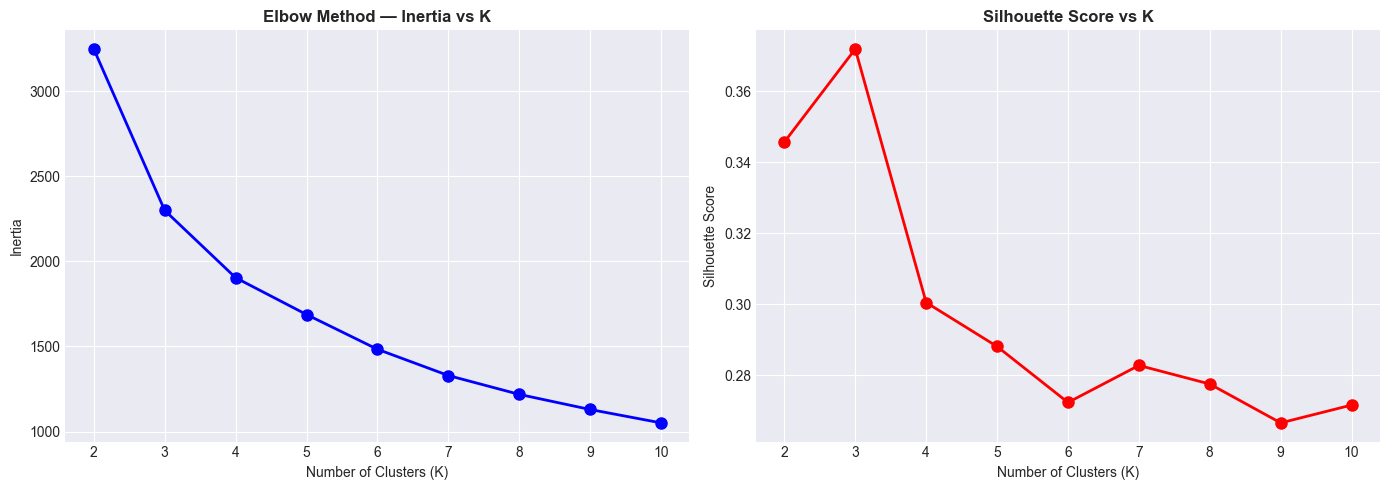

✅ Best K by silhouette: 3


In [3]:
inertias    = []
silhouettes = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../outputs/plots/05_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"✅ Best K by silhouette: {best_k}")

K-Means Anomaly Detector

In [4]:
BEST_K = best_k  # from cell above
Q_THRESHOLD = 97.5  # 97.5th percentile = ~2.5% flag rate

# Fit on train
km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
km.fit(X_train)

# Per-cluster distance thresholds on train
train_labels   = km.predict(X_train)
train_distances = np.linalg.norm(X_train - km.cluster_centers_[train_labels], axis=1)

cluster_thresholds = {}
for c in range(BEST_K):
    mask = train_labels == c
    cluster_thresholds[c] = np.percentile(train_distances[mask], Q_THRESHOLD)

def kmeans_anomaly(X, labels, thresholds):
    distances = np.linalg.norm(X - km.cluster_centers_[labels], axis=1)
    flags = np.array([
        int(distances[i] > thresholds[labels[i]])
        for i in range(len(X))
    ])
    return flags, distances

# Score val and test
val_labels  = km.predict(X_val)
test_labels = km.predict(X_test)

val_km_flags,  val_km_dist  = kmeans_anomaly(X_val,  val_labels,  cluster_thresholds)
test_km_flags, test_km_dist = kmeans_anomaly(X_test, test_labels, cluster_thresholds)

val['km_flag']   = val_km_flags
val['km_dist']   = val_km_dist
test['km_flag']  = test_km_flags
test['km_dist']  = test_km_dist

print(f"✅ K-Means done! (K={BEST_K})")
print(f"Val  anomalies: {val_km_flags.sum()} / {len(val_km_flags)} ({val_km_flags.mean()*100:.2f}%)")
print(f"Test anomalies: {test_km_flags.sum()} / {len(test_km_flags)} ({test_km_flags.mean()*100:.2f}%)")

✅ K-Means done! (K=3)
Val  anomalies: 57 / 2268 (2.51%)
Test anomalies: 25 / 567 (4.41%)


DBSCAN Anomaly Detector

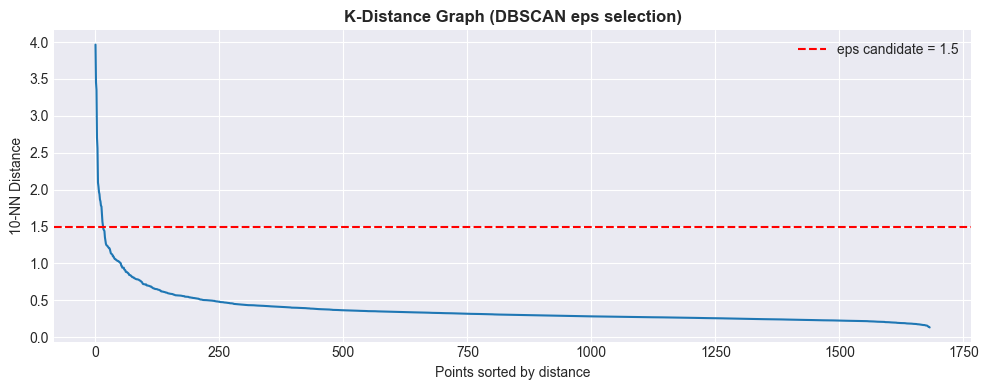

✅ DBSCAN train fit | eps=1.5 | noise points: 6 (0.36%)
Val  DBSCAN anomalies: 5 (0.22%)
Test DBSCAN anomalies: 3 (0.53%)


In [5]:
from sklearn.neighbors import NearestNeighbors

# Find best eps using k-distance elbow on train
MIN_SAMPLES = 10
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_train)
distances, _ = nbrs.kneighbors(X_train)
k_distances  = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, linewidth=1.5)
plt.title('K-Distance Graph (DBSCAN eps selection)', fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-NN Distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps candidate = 1.5')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/06_dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

# Fit DBSCAN on train
EPS = 1.5
db_train = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X_train)
train_noise = (db_train.labels_ == -1).sum()
print(f"✅ DBSCAN train fit | eps={EPS} | noise points: {train_noise} ({train_noise/len(X_train)*100:.2f}%)")

# Walk-forward scoring on val and test
def dbscan_walkforward(X_base, X_new, eps, min_samples):
    X_combined = np.vstack([X_base, X_new])
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_combined)
    new_labels = db.labels_[len(X_base):]
    return (new_labels == -1).astype(int)

val_db_flags  = dbscan_walkforward(X_train, X_val,  EPS, MIN_SAMPLES)
test_db_flags = dbscan_walkforward(X_train, X_test, EPS, MIN_SAMPLES)

val['db_flag']  = val_db_flags
test['db_flag'] = test_db_flags

print(f"Val  DBSCAN anomalies: {val_db_flags.sum()} ({val_db_flags.mean()*100:.2f}%)")
print(f"Test DBSCAN anomalies: {test_db_flags.sum()} ({test_db_flags.mean()*100:.2f}%)")

Consensus (Union + Intersection)

In [6]:
# Union = flagged by EITHER model
# Intersection = flagged by BOTH models
val['consensus_union']        = ((val['km_flag'] == 1) | (val['db_flag'] == 1)).astype(int)
val['consensus_intersection'] = ((val['km_flag'] == 1) & (val['db_flag'] == 1)).astype(int)

test['consensus_union']        = ((test['km_flag'] == 1) | (test['db_flag'] == 1)).astype(int)
test['consensus_intersection'] = ((test['km_flag'] == 1) & (test['db_flag'] == 1)).astype(int)

print("=== VAL SET ===")
print(f"K-Means flags    : {val['km_flag'].sum()} ({val['km_flag'].mean()*100:.2f}%)")
print(f"DBSCAN flags     : {val['db_flag'].sum()} ({val['db_flag'].mean()*100:.2f}%)")
print(f"Union flags      : {val['consensus_union'].sum()} ({val['consensus_union'].mean()*100:.2f}%)")
print(f"Intersection flags: {val['consensus_intersection'].sum()} ({val['consensus_intersection'].mean()*100:.2f}%)")

print("\n=== TEST SET (COVID PERIOD!) ===")
print(f"K-Means flags    : {test['km_flag'].sum()} ({test['km_flag'].mean()*100:.2f}%)")
print(f"DBSCAN flags     : {test['db_flag'].sum()} ({test['db_flag'].mean()*100:.2f}%)")
print(f"Union flags      : {test['consensus_union'].sum()} ({test['consensus_union'].mean()*100:.2f}%)")
print(f"Intersection flags: {test['consensus_intersection'].sum()} ({test['consensus_intersection'].mean()*100:.2f}%)")

=== VAL SET ===
K-Means flags    : 57 (2.51%)
DBSCAN flags     : 5 (0.22%)
Union flags      : 58 (2.56%)
Intersection flags: 4 (0.18%)

=== TEST SET (COVID PERIOD!) ===
K-Means flags    : 25 (4.41%)
DBSCAN flags     : 3 (0.53%)
Union flags      : 25 (4.41%)
Intersection flags: 3 (0.53%)


 Visualize Anomalies on Price Chart

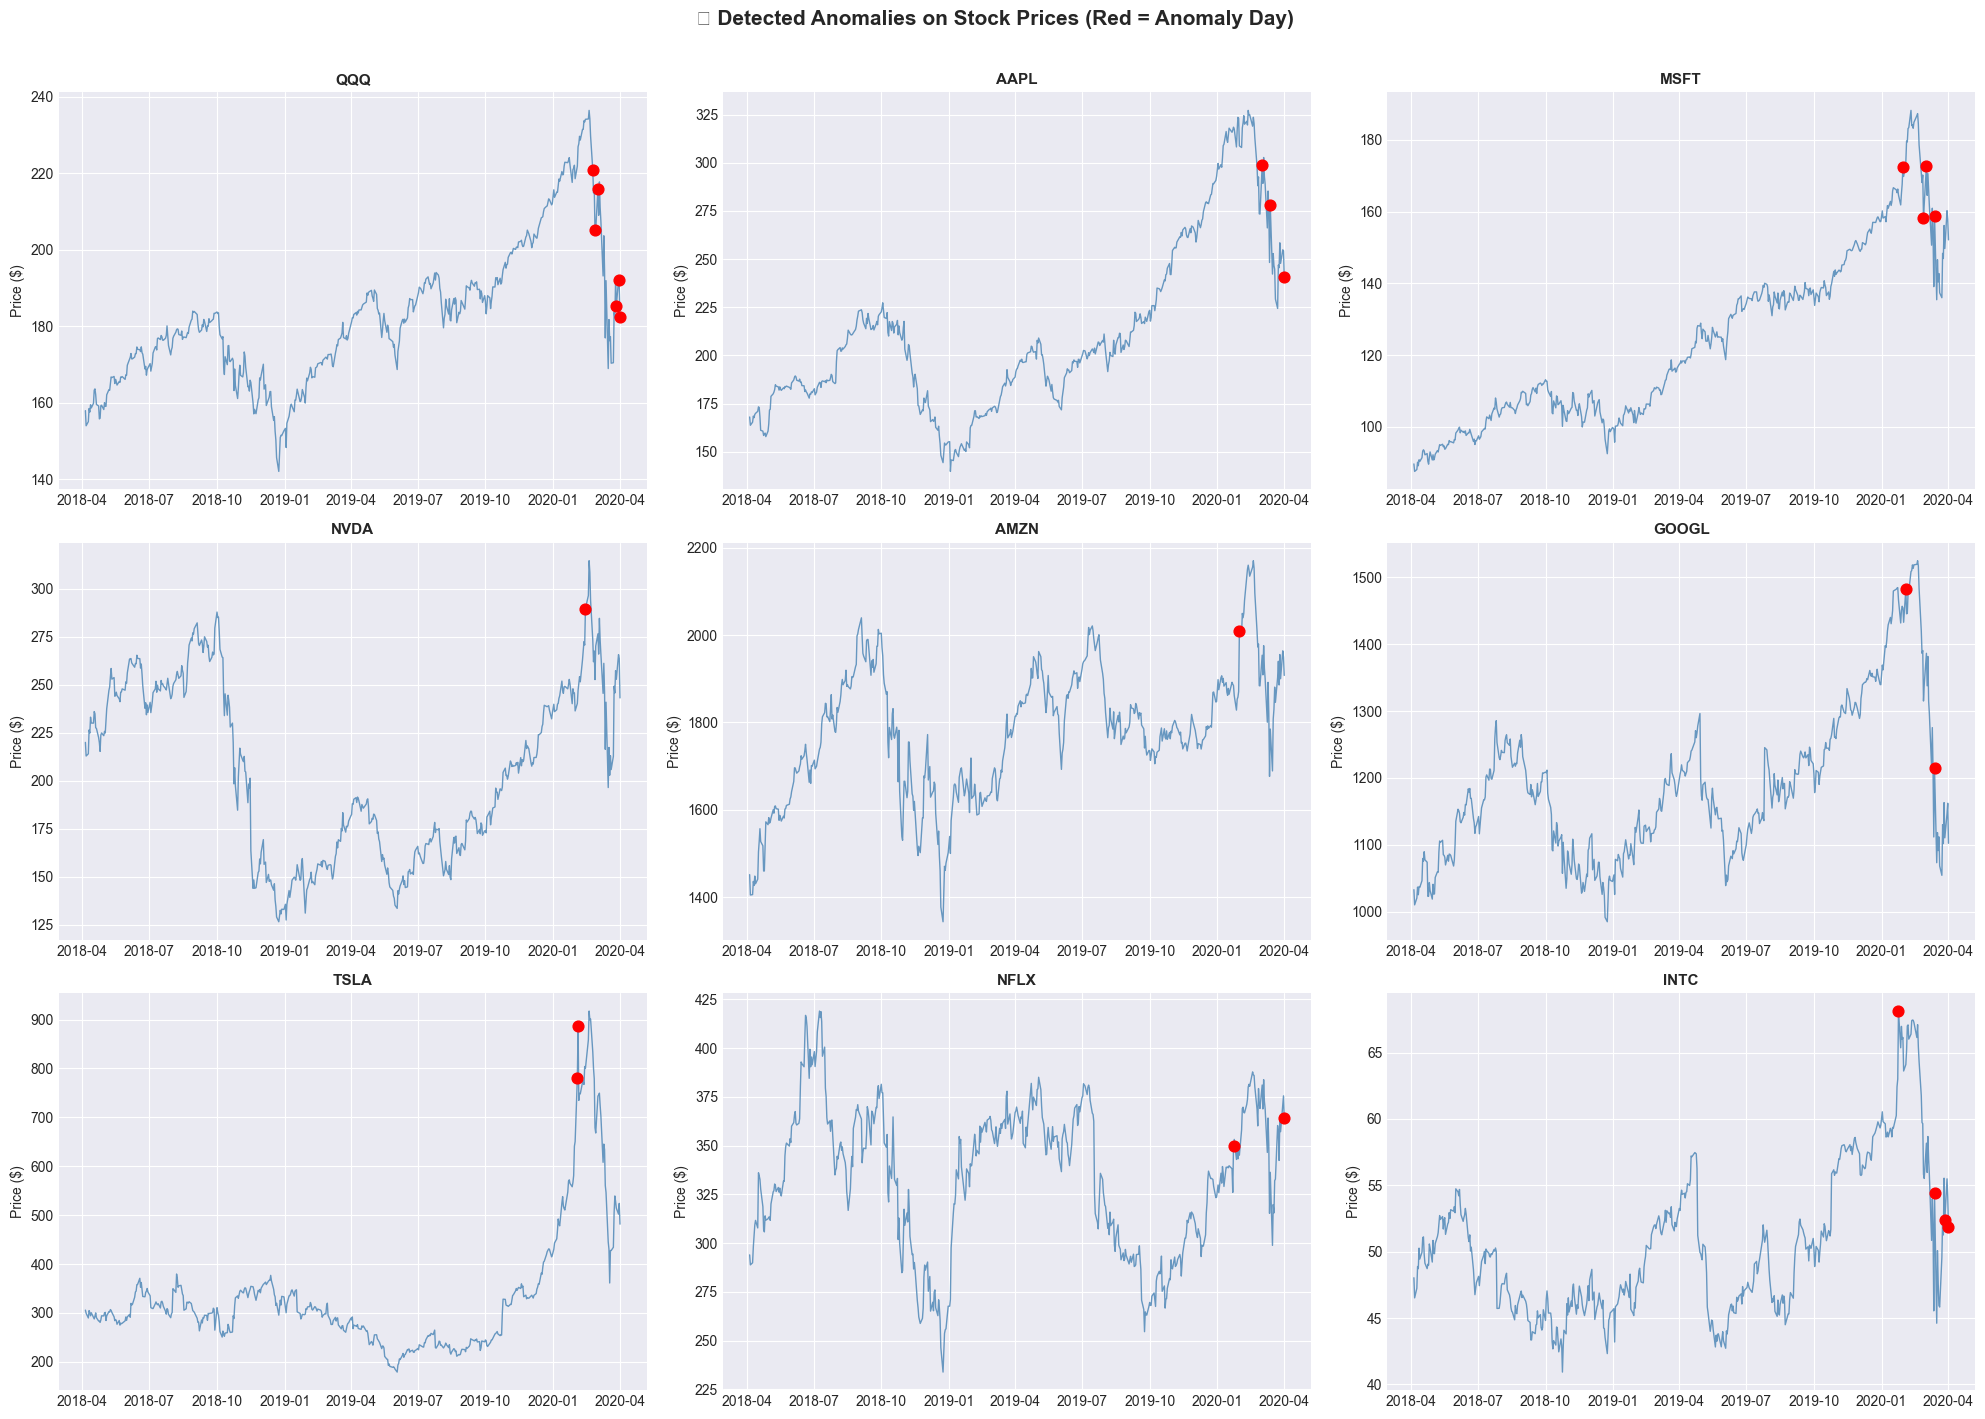

✅ Anomaly visualization saved!


In [7]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for i, ticker in enumerate(['QQQ','AAPL','MSFT','NVDA','AMZN','GOOGL','TSLA','NFLX','INTC']):
    ax = axes[i]
    
    # Full price history
    full = featured[featured['Ticker'] == ticker]
    ax.plot(full['Date'], full['Adj Close'], linewidth=1, color='steelblue', alpha=0.8)
    
    # Test anomalies for this ticker
    t_ticker = test[test['Ticker'] == ticker]
    anomalies = t_ticker[t_ticker['consensus_union'] == 1]
    
    if len(anomalies) > 0:
        # Get price for anomaly dates
        anomaly_prices = full[full['Date'].isin(anomalies['Date'])][['Date','Adj Close']]
        ax.scatter(anomaly_prices['Date'], anomaly_prices['Adj Close'],
                   color='red', s=60, zorder=5, label='Anomaly')
    
    ax.set_title(f'{ticker}', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Price ($)')

plt.suptitle('🚨 Detected Anomalies on Stock Prices (Red = Anomaly Day)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/07_anomalies_on_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Anomaly visualization saved!")

Save Final Outputs (CSV)

In [8]:
# Daily Anomaly Card
anomaly_card = test[test['consensus_union'] == 1][[
    'Date', 'Ticker', 'ret', 'ret_z', 'vol_z', 'range_pct',
    'km_flag', 'db_flag', 'consensus_union', 'type'
]].copy()
anomaly_card = anomaly_card.sort_values(['Date', 'Ticker']).reset_index(drop=True)
anomaly_card.to_csv('../outputs/csv/daily_anomaly_card.csv', index=False)

# Market Day Table
market_test = market[market['Date'] >= '2020-01-01'][[
    'Date', 'market_ret', 'breadth', 'market_anomaly_flag', 'flag_rate'
]]
market_test.to_csv('../outputs/csv/market_day_table.csv', index=False)

print(f"✅ Daily Anomaly Card saved! {len(anomaly_card)} anomalous stock-days")
print(f"✅ Market Day Table saved! {market_test['market_anomaly_flag'].sum()} anomalous market days")
print("\n📋 Sample Anomaly Card:")
print(anomaly_card[['Date','Ticker','ret','ret_z','vol_z','type']].head(10).to_string())

✅ Daily Anomaly Card saved! 25 anomalous stock-days
✅ Market Day Table saved! 28 anomalous market days

📋 Sample Anomaly Card:
        Date Ticker       ret     ret_z     vol_z                              type
0 2020-01-23   NFLX  0.072393  3.928759  2.358018               spike+range_extreme
1 2020-01-24   INTC  0.081333  5.596721  3.955313  spike+volume_shock+range_extreme
2 2020-01-30   MSFT  0.028208  3.131593  3.958166  spike+volume_shock+range_extreme
3 2020-01-31   AMZN  0.073791  7.007576  6.447519  spike+volume_shock+range_extreme
4 2020-02-03  GOOGL  0.034772  3.502743  3.293683                spike+volume_shock
5 2020-02-03   TSLA  0.198949  6.727760  2.591031  spike+volume_shock+range_extreme
6 2020-02-04   TSLA  0.137256  3.356831  2.884892  spike+volume_shock+range_extreme
7 2020-02-14   NVDA  0.070205  3.592206  3.623783                spike+volume_shock
8 2020-02-24    QQQ -0.038563 -4.942998  3.278128                crash+volume_shock
9 2020-02-27   MSFT -0.070459 -5.